# Central North Greenland (Victoria Fjord) dolerite dykes ca. 1382 Ma paleomagnetic pole

## Geologic context

These middle-Proterozoic basic dykes cut Archaean basement exposed as nunataks at
the head of Victoria Fjord in central North Greenland (81.5°N, 44.7°W;
Abrahamsen & Van der Voo, 1987). Their characteristic remanence is of a single
polarity that is antiparallel to that of the comagmatic Zig-Zag Dal Basalts and
Midsommerso Dolerites of eastern North Greenland, and confirms that Greenland was
part of the North American craton in the Mesoproterozoic. The dyke magnetization
is shown to be primary by a detailed positive baked-contact test.

## Paleomagnetic And Rock Magnetic Data

- B = 12 sites, N = 92 samples; mean direction DEC/INC = 265.2°/21.5°; K = 60.0.
- Field/statistical tests noted in compilation: C+.
- Rock-magnetic interpretation: expand with mineral carriers/coercivity/unblocking evidence from source studies.

## Age Constraints

- Current bracket: lomagage 1380.0 Ma, himagage 1384.0 Ma.
- Compilation method note: There is no direct radiometric dates from these dikes in the nunatak area, the age of the magnetization is inferred from the fact that the dikes' directions look to be antipodal to the directions reported from the Midsommersoe dolerite. U-Pb dating of baddeleyite from intrusive Midsommersø Dolerites yields an age of 1382 ± 2 Ma (Upton et al., 2005)

## References

- Paleomagnetic source: Abrahamsen, N., Van der Voo, R. (1987). Palaeomagnetism of middle Proterozoic (c.1.25 Ga) dykes from central North Greenland. Geophys.JRAS, 91, 597-611.
- Geochronology / age-constraint note (compilation): U-Pb dating of baddeleyite from intrusive Midsommersø Dolerites yields an age of 1382 ± 2 Ma (Upton et al., 2005); Upton, B. G. J., Rämö, O. T., Heaman, L. M., Blichert-Toft, J., Kalsbeek, F., Barry, T. L., & Jepsen, H. F. (2005). The Mesoproterozoic Zig-Zag Dal basalts and associated intrusions of eastern North Greenland: Mantle plume–lithosphere interaction. Contributions to Mineralogy and Petrology, 149(1), 40–56. https://doi.org/10.1007/s00410-004-0634-7

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data and the dyke pole

Loaded from `../data/1382_Victoria_Fjord/`. The pole uses the 9 accepted dyke
sites (D1-D9); D10 (a discordant easterly direction, α95 18.5°) is excluded.

In [2]:
sites_geo, _ = pt.load_magic_sites('../data/1382_Victoria_Fjord/sites.txt')
study_lat, study_lon = 81.5, 315.3
print(f'{len(sites_geo)} accepted dyke sites')
sites_geo[['site', 'lat', 'lon', 'dir_dec', 'dir_inc', 'dir_alpha95', 'dir_k', 'dir_n_samples', 'vgp_lat', 'vgp_lon']]

9 accepted dyke sites


,site,lat,lon,dir_dec,dir_inc,dir_alpha95,dir_k,dir_n_samples,vgp_lat,vgp_lon
0,D1,81.5,315.3,265.0,21.0,7.6,41.0,10.0,10.0,231.9
1,D2,81.5,315.3,264.0,29.0,7.9,38.0,10.0,14.4,233.6
2,D3,81.5,315.3,273.0,20.0,4.4,121.0,10.0,10.6,223.9
3,D4,81.5,315.3,268.0,21.0,5.5,150.0,6.0,10.4,228.9
4,D5,81.5,315.3,274.0,14.0,1.6,1807.0,6.0,7.6,222.4
5,D6,81.5,315.3,275.0,28.0,4.6,149.0,8.0,15.5,222.6
6,D7,81.5,315.3,258.0,29.0,6.1,72.0,9.0,13.6,239.4
7,D8,81.5,315.3,260.0,37.0,6.9,56.0,5.0,18.9,238.3
8,D9,81.5,315.3,256.0,27.0,6.2,152.0,5.0,12.1,241.2


Plon: 231.3  Plat: 12.7
Number of directions in mean (n): 9
Angular radius of 95% confidence (A_95): 5.1
Precision parameter (k) estimate: 104.1

prior compilation (Victoria Fjord, GPMDB 489): 10.3 N / 231.7 E, A95 5.9, N=12
Abrahamsen & Van der Voo (1987) observed pole (before rotation): ~12.5 N / 232 E


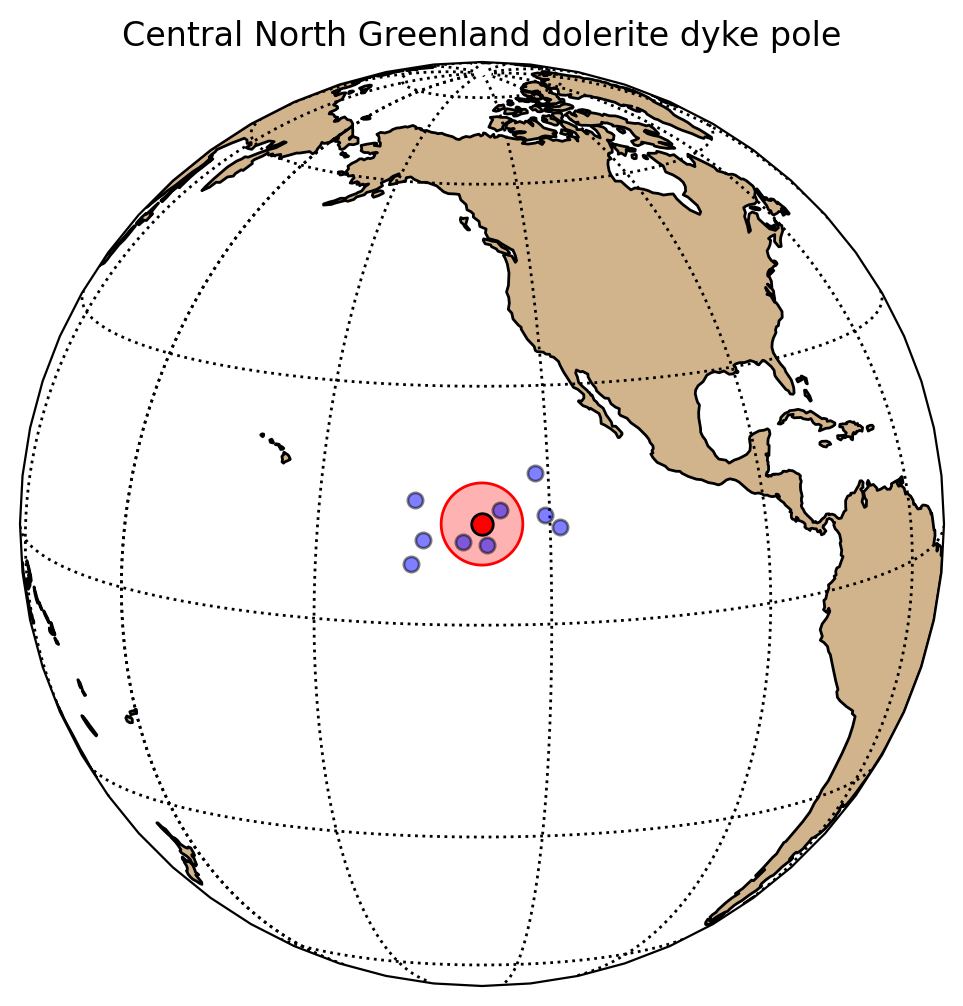

In [3]:
vgp_block, pole_mean = pt.compute_mean_pole(sites_geo, unify_polarity=True)
if pole_mean['inc'] < 0:
    vgp_block, pole_mean = pt.compute_mean_pole(sites_geo, unify_polarity=True, flip=True)
ipmag.print_pole_mean(pole_mean)
print('\nprior compilation (Victoria Fjord, GPMDB 489): 10.3 N / 231.7 E, A95 5.9, N=12')
print('Abrahamsen & Van der Voo (1987) observed pole (before rotation): ~12.5 N / 232 E')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Central North Greenland dolerite dyke pole')
plt.show()

Dec: 266.1  Inc: 25.3
Number of directions in mean (n): 9
Angular radius of 95% confidence (a_95): 5.9
Precision parameter (k) estimate: 75.8


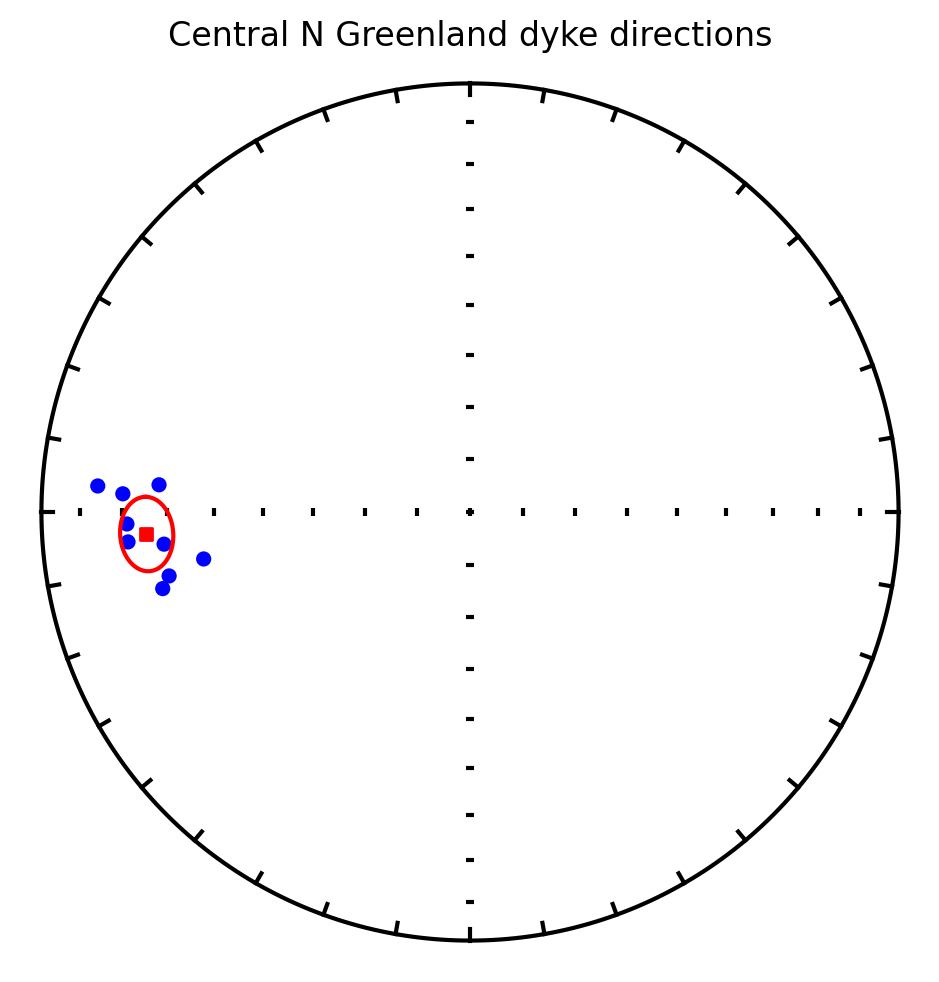

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(sites_geo, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)
ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], color='red', marker='s')
plt.title('Central N Greenland dyke directions')
plt.show()

## Field test: baked contact

Abrahamsen & Van der Voo (1987) sampled three baked gneiss sites adjacent to the
dykes; the baked Archaean gneiss carries the dyke direction, a positive
baked-contact test confirming the dyke magnetization is primary (the baked-gneiss
sites are not in this site-level table but are documented in the paper).

## Paleosecular variation

A_95 of 5.1 passes Deenen et al. (2011) criteria of being between 5.0 and 20.5 for this number of sites


<AxesSubplot:title={'center':'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

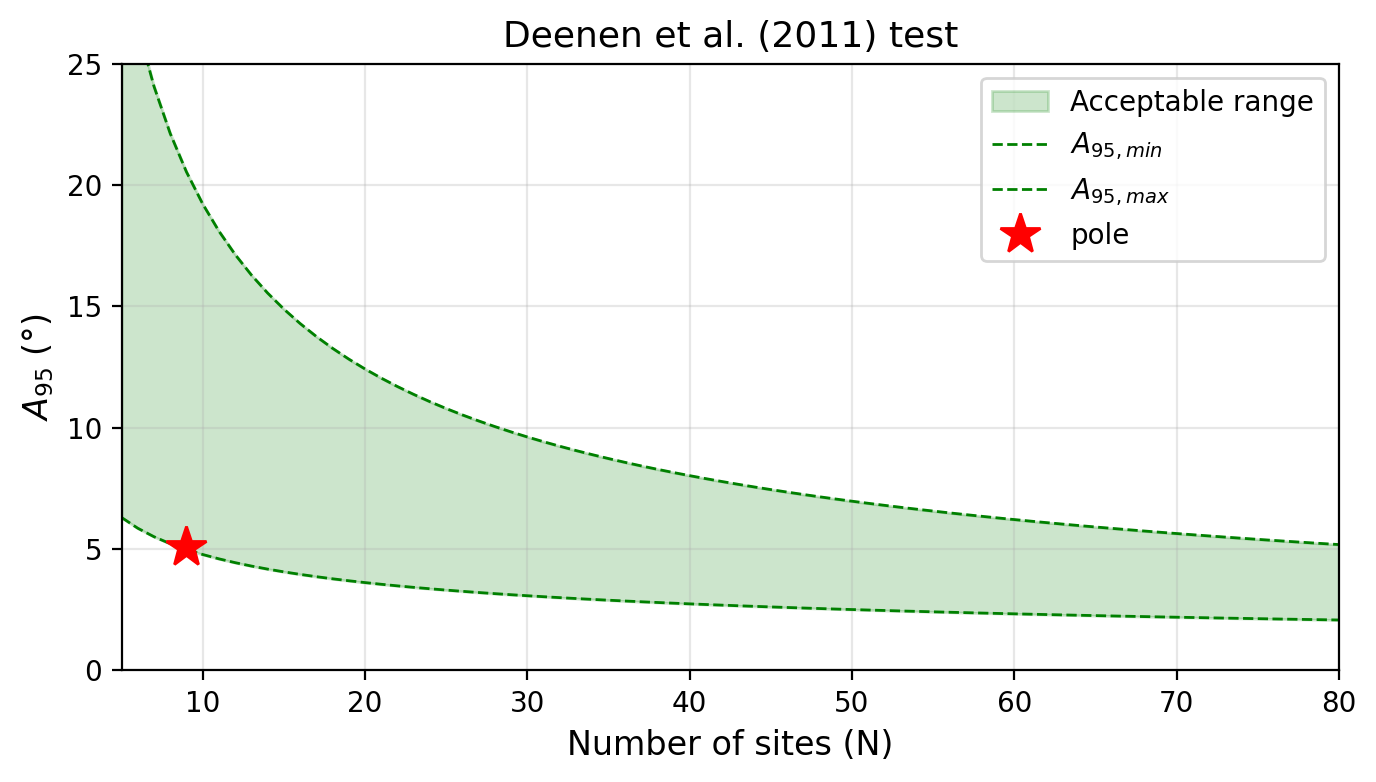

In [5]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are drawn from a
Fisher distribution, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD paleosecular-variation model expectation
at the sampling paleolatitude.

In [6]:
fishqq_result = pt.fishqq_vgps(sites_geo, unify_polarity=True)
fishqq_result

you need N> 10 for at least one mode


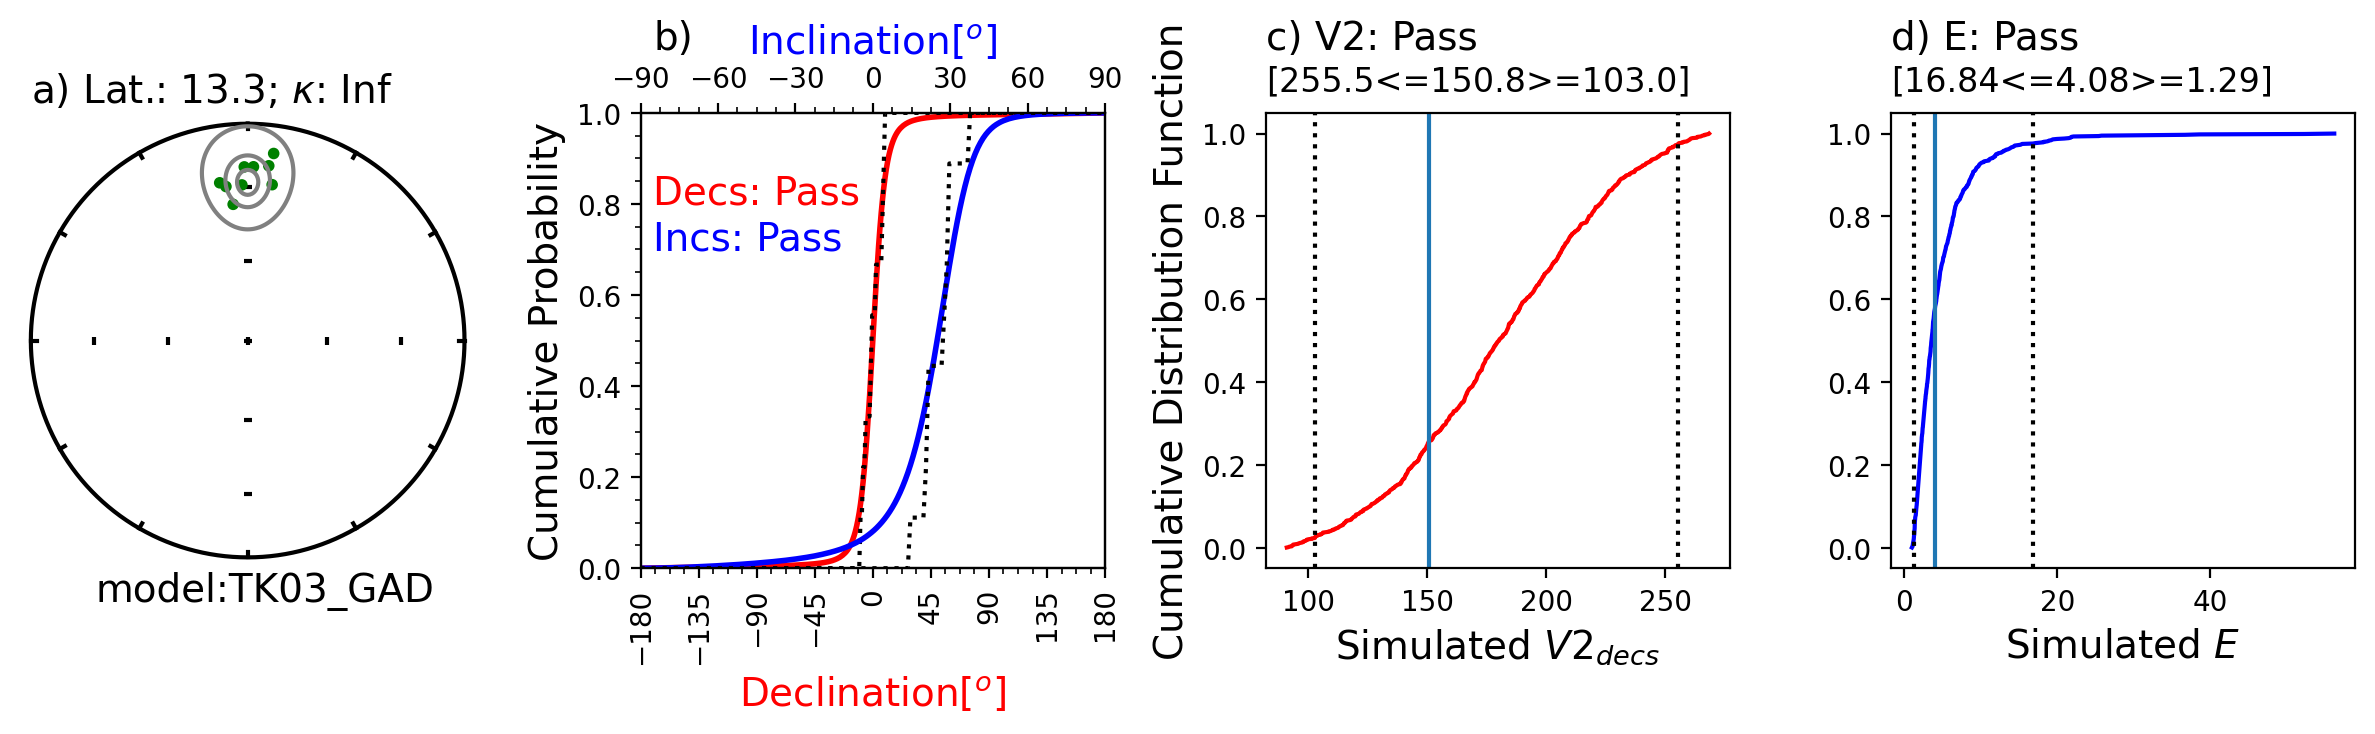

paleolatitude = 13.3 deg; elongation E = 4.08 (consistent with TK03.GAD)


In [7]:
_slat, _slon = float(sites_geo['lat'].mean()), float(sites_geo['lon'].mean())
try:
    svei_result = pt.svei_test_vgps(sites_geo, _slon, _slat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(sites_geo, _slon, _slat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## Euler rotation into the Laurentia reference frame

These rocks belong to the Laurentia-Greenland terrane, so the pole must be restored into the Laurentia reference frame before it is compared with the Laurentia APWP. The Greenland-to-Laurentia rotation of Roest & Srivastava (1989), associated with Cenozoic opening of Baffin Bay and the Labrador Sea, is applied with `pmag.pt_rot`: Euler pole 67.5 deg N / -118.5 deg E, angle -13.8 deg. This is the same rotation `get_Laurentia_poles` uses to place the Greenland comparison poles into Laurentia coordinates.

In [8]:
euler_greenland = pt.TERRANE_EULER_POLES['Laurentia-Greenland']   # [67.5, -118.5, -13.8]; Roest & Srivastava (1989)
rlat, rlon = pmag.pt_rot(euler_greenland, [pole_mean['inc']], [pole_mean['dec']])
pole_rotated = {'inc': rlat[0], 'dec': rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"unrotated (present-day Greenland frame): {pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E")
print(f"rotated into the Laurentia frame:        {pole_rotated['inc']:.1f} N / {pole_rotated['dec']:.1f} E")

unrotated (present-day Greenland frame): 12.7 N / 231.3 E
rotated into the Laurentia frame:        14.1 N / 219.8 E


## The pole in the context of the Laurentia APWP

The pole is shown in its unrotated position (present-day Greenland coordinates, off the Laurentia path) and rotated into the Laurentia frame (restored onto the path). The comparison APWP poles are all shown in Laurentia coordinates.

posx and posy should be finite values
posx and posy should be finite values


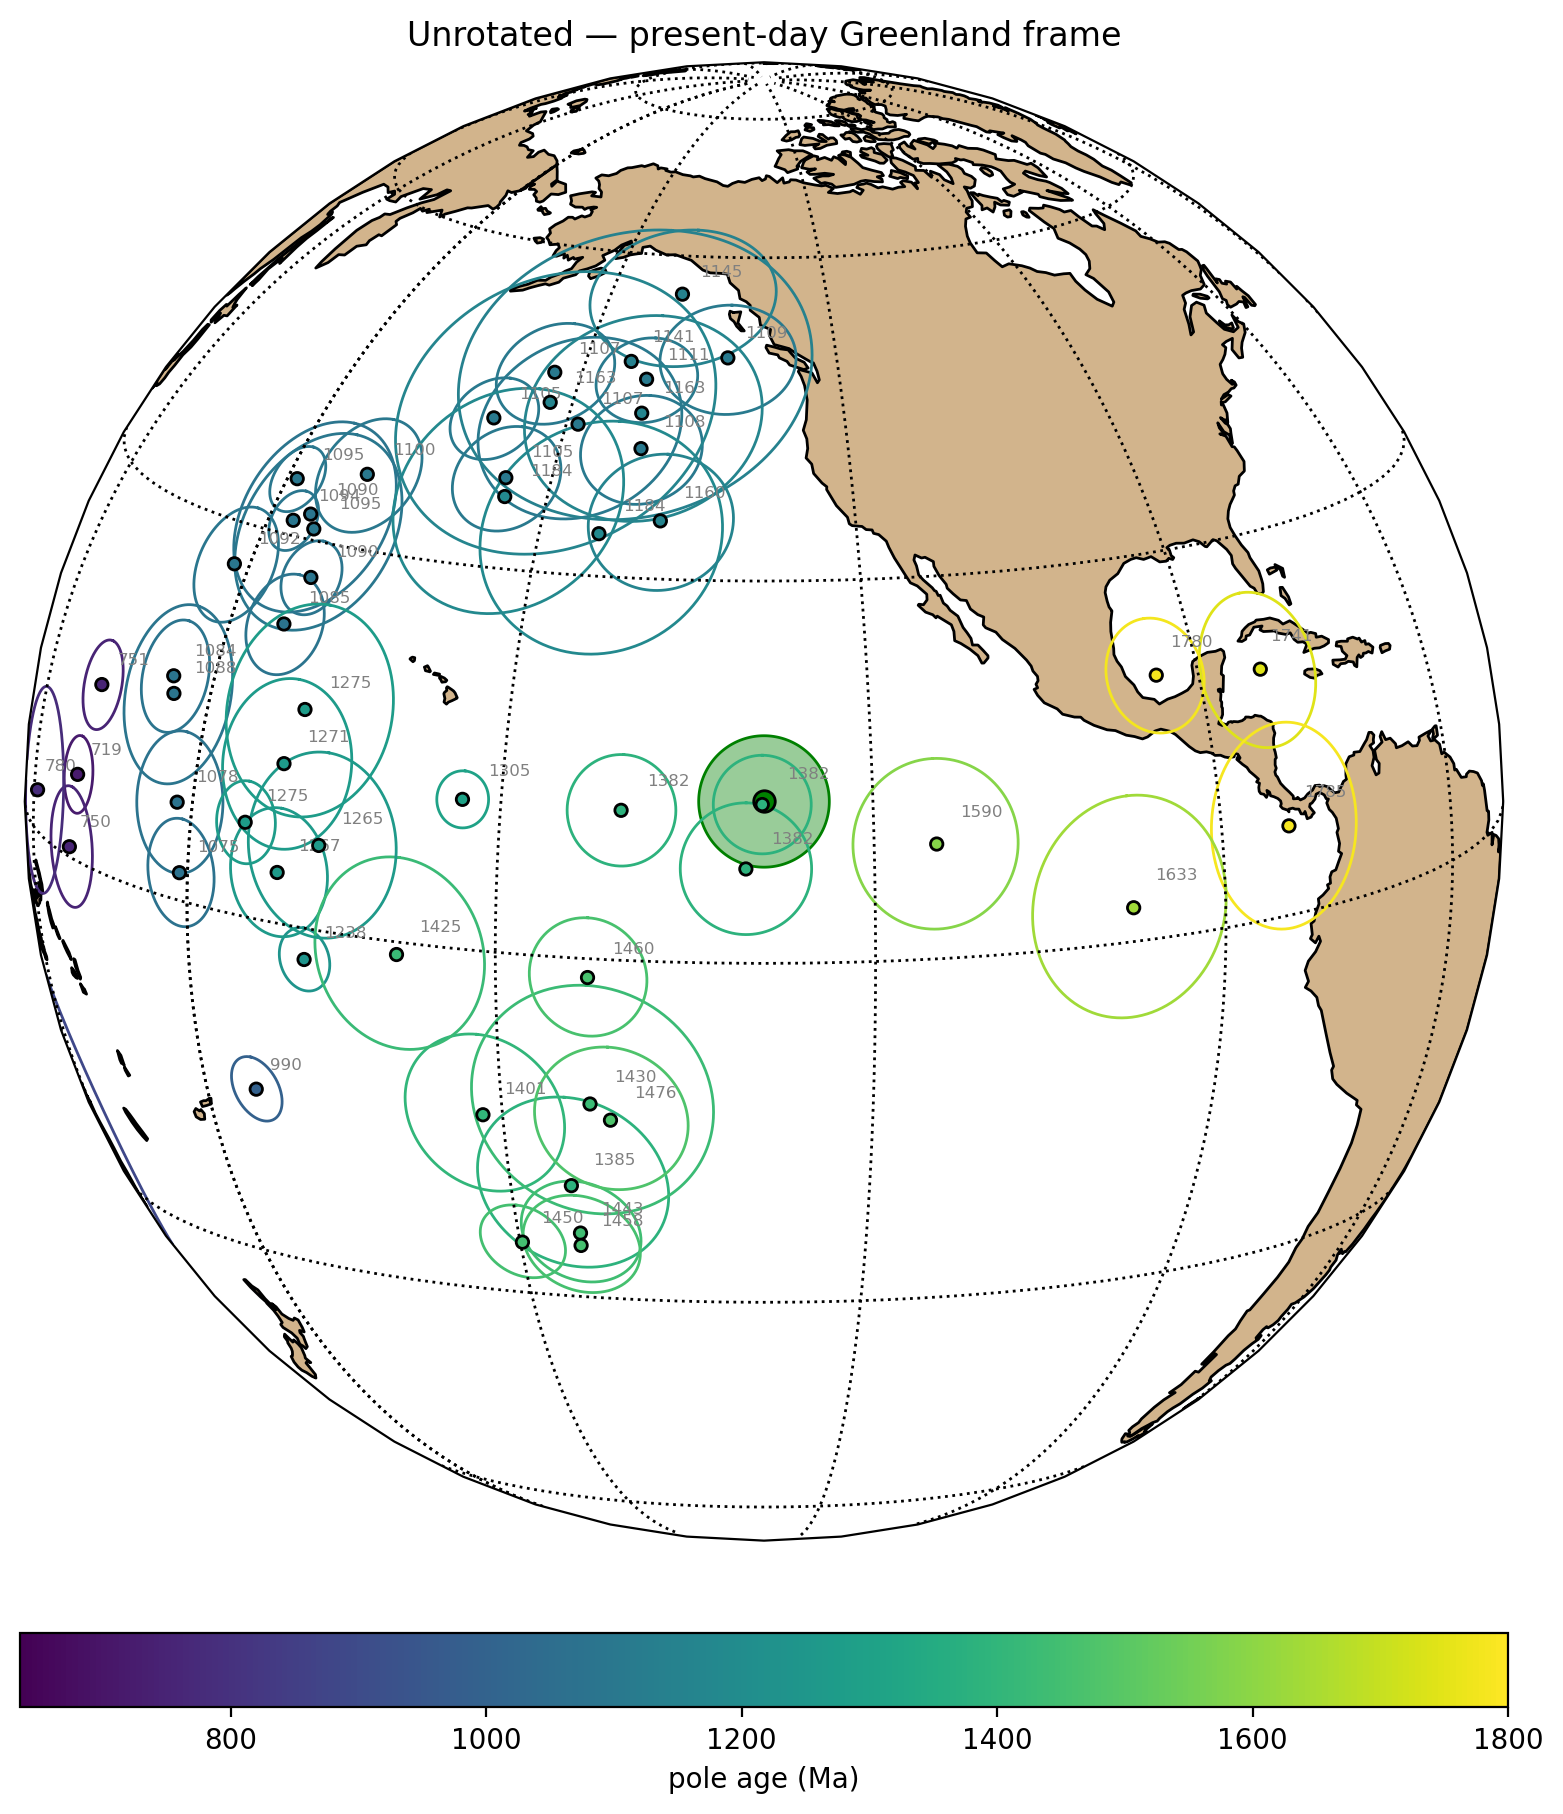

In [9]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.title('Unrotated \u2014 present-day Greenland frame')
plt.show()

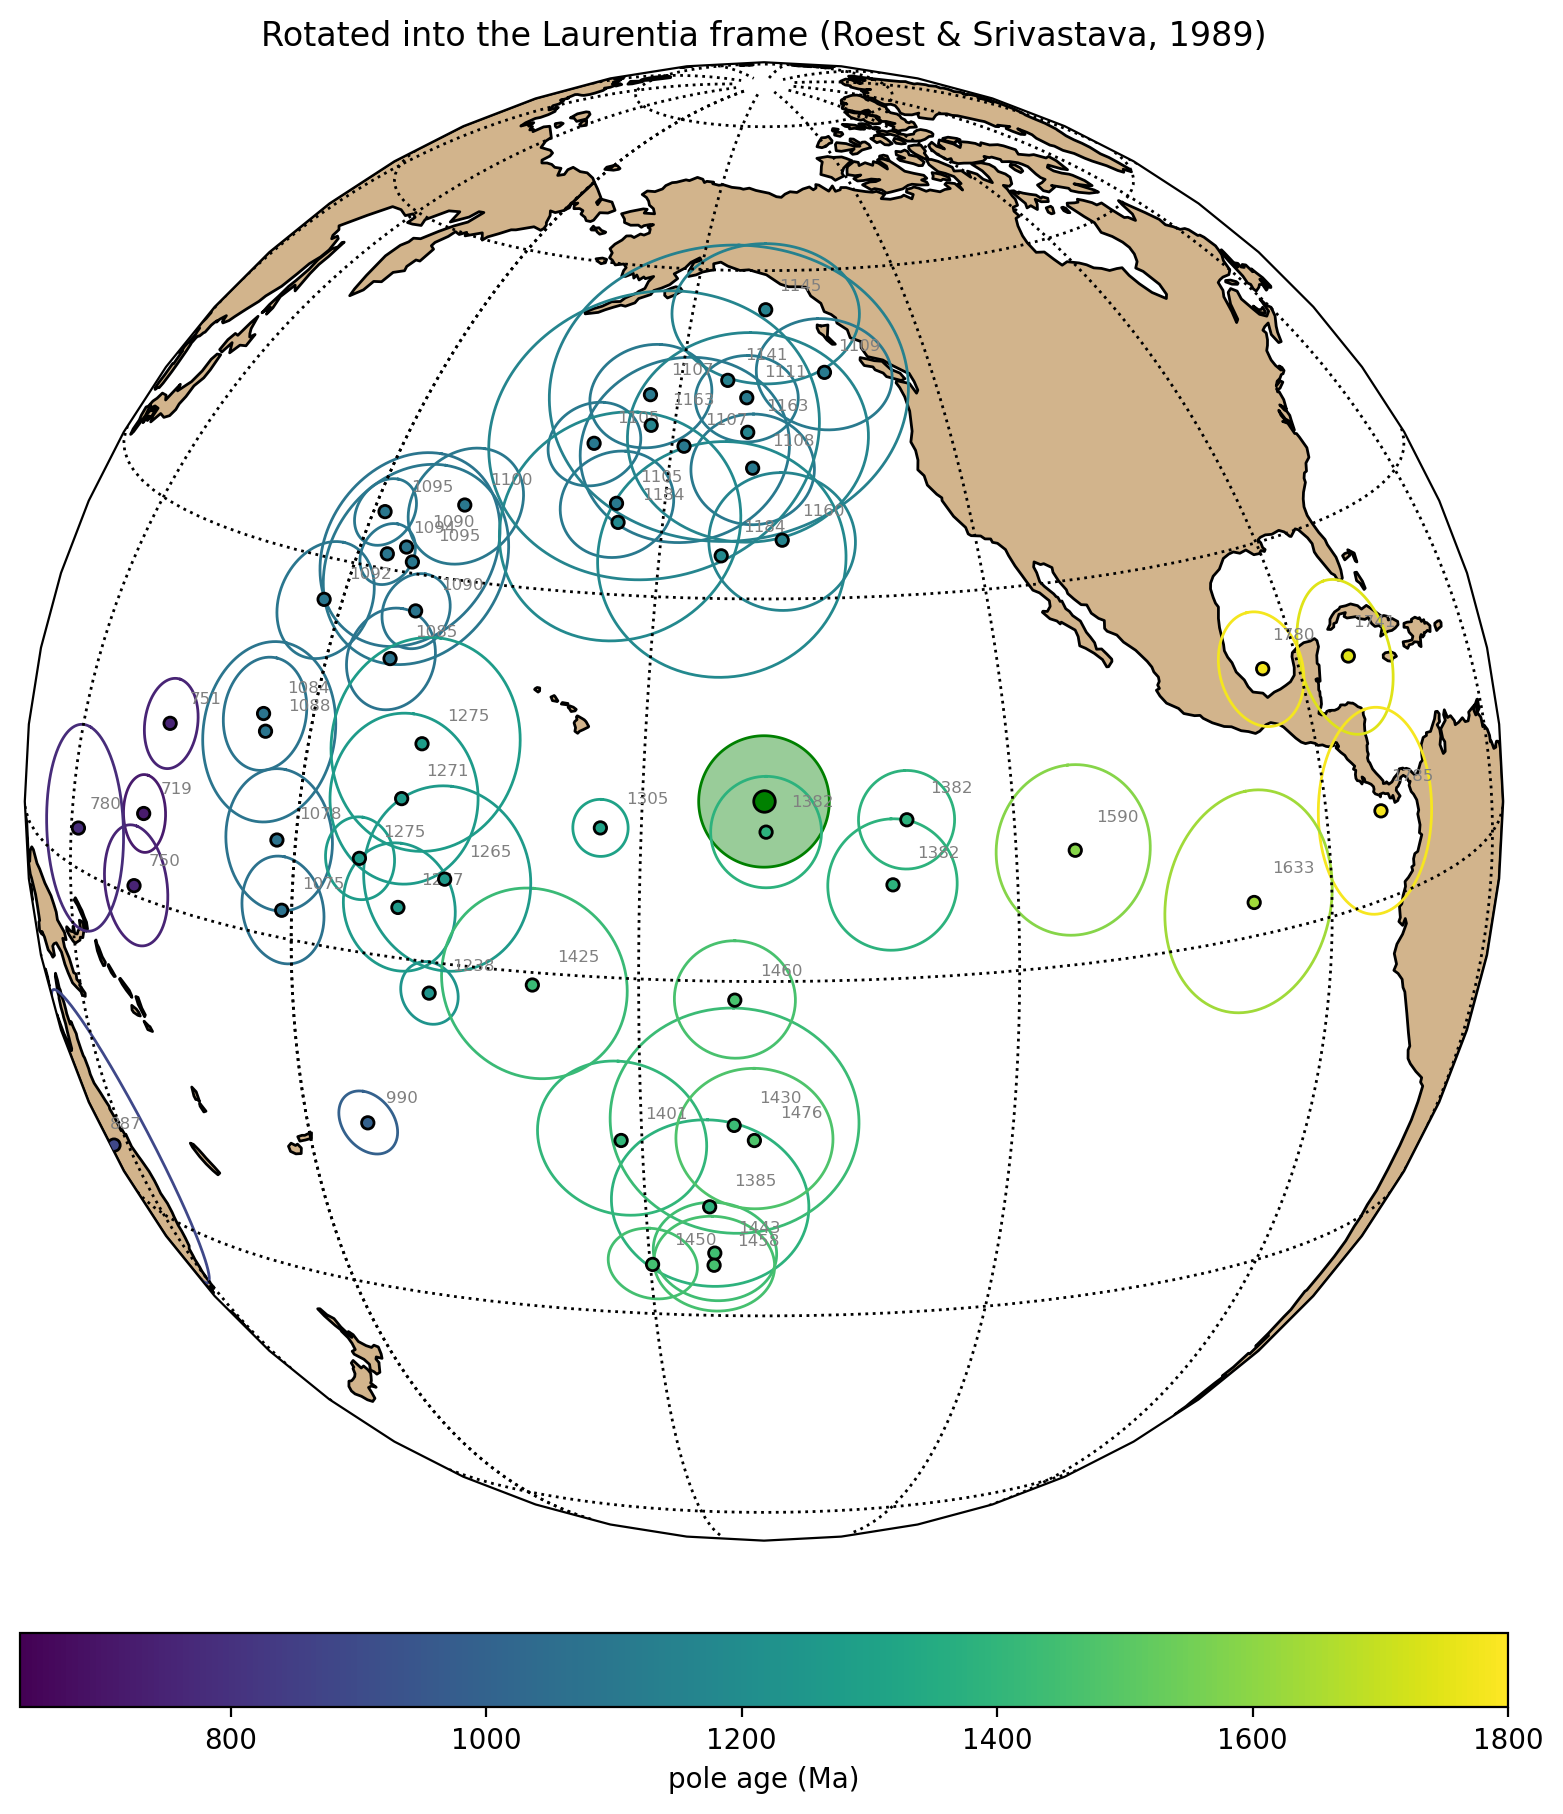

In [10]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_rotated['inc'], pole_rotated['dec'],
                          pole_rotated['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_rotated['dec'],
                          central_latitude=pole_rotated['inc'])
plt.title('Rotated into the Laurentia frame (Roest & Srivastava, 1989)')
plt.show()

## R7: comparison with younger Laurentia poles

The `plot_pole_overlap` comparison is shown for both the unrotated and the rotated position.

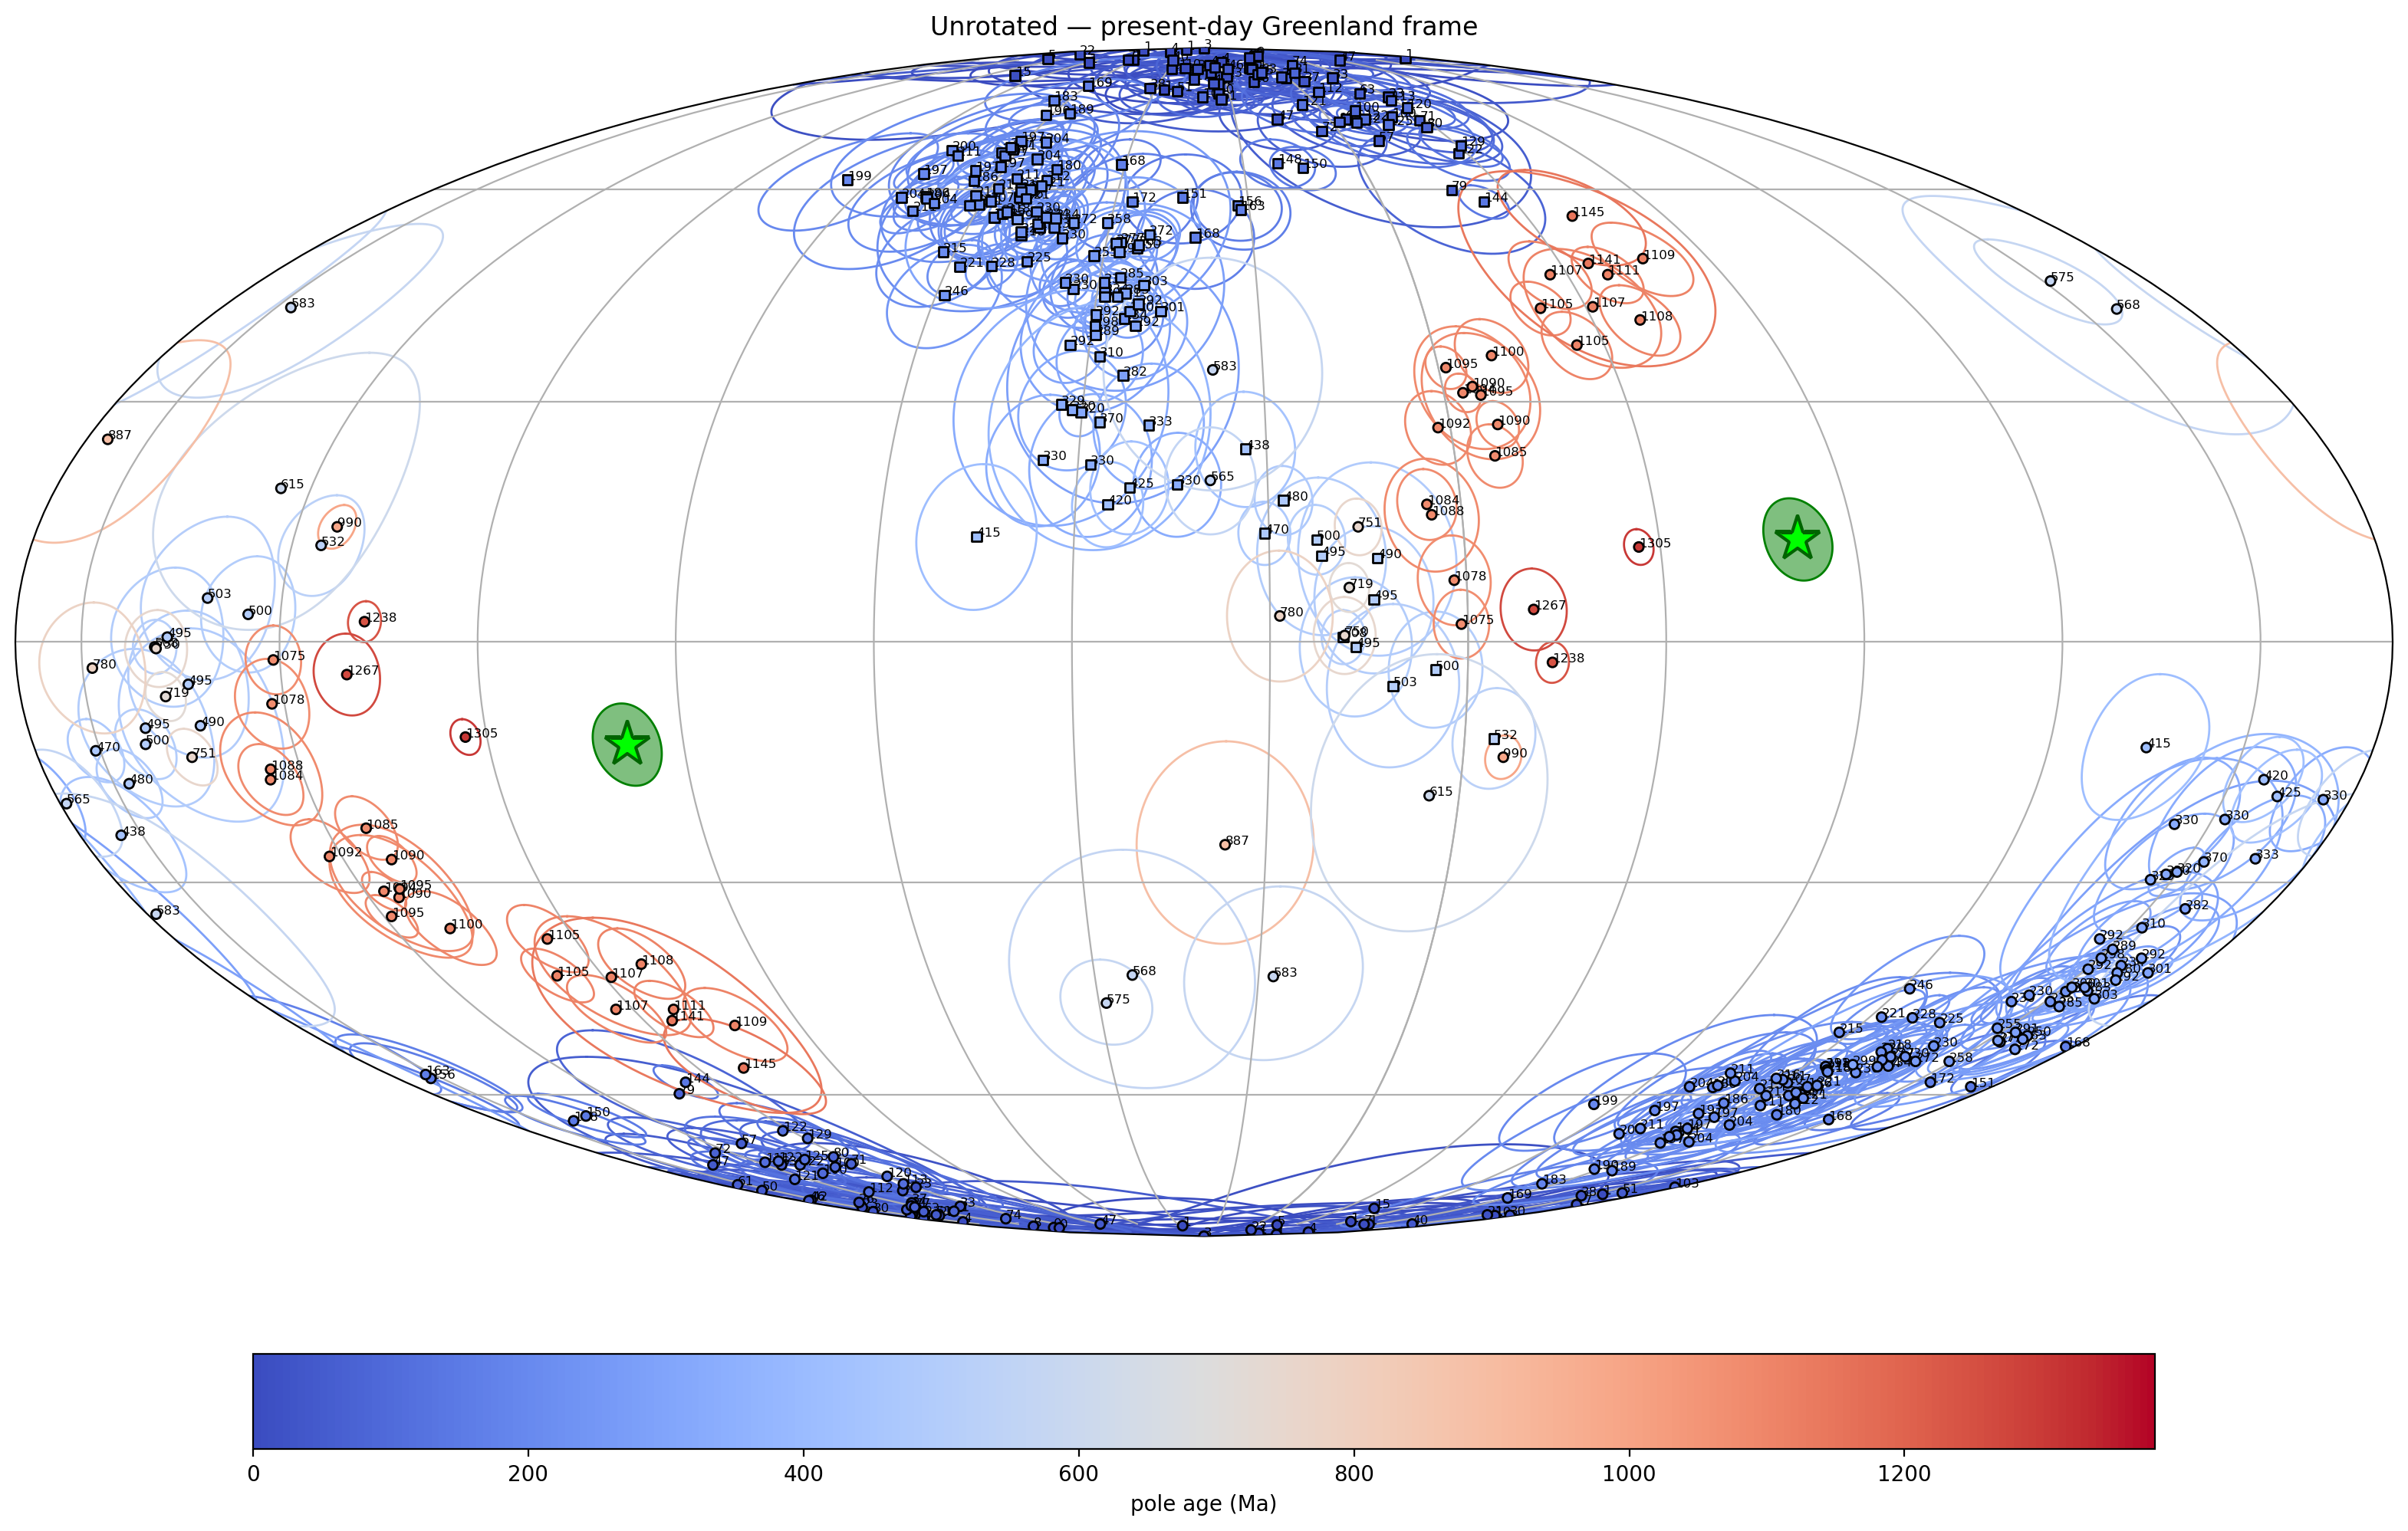

In [11]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Victoria Fjord dolerite dykes', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1382, show=False)
plt.title('Unrotated \u2014 present-day Greenland frame')
plt.show()

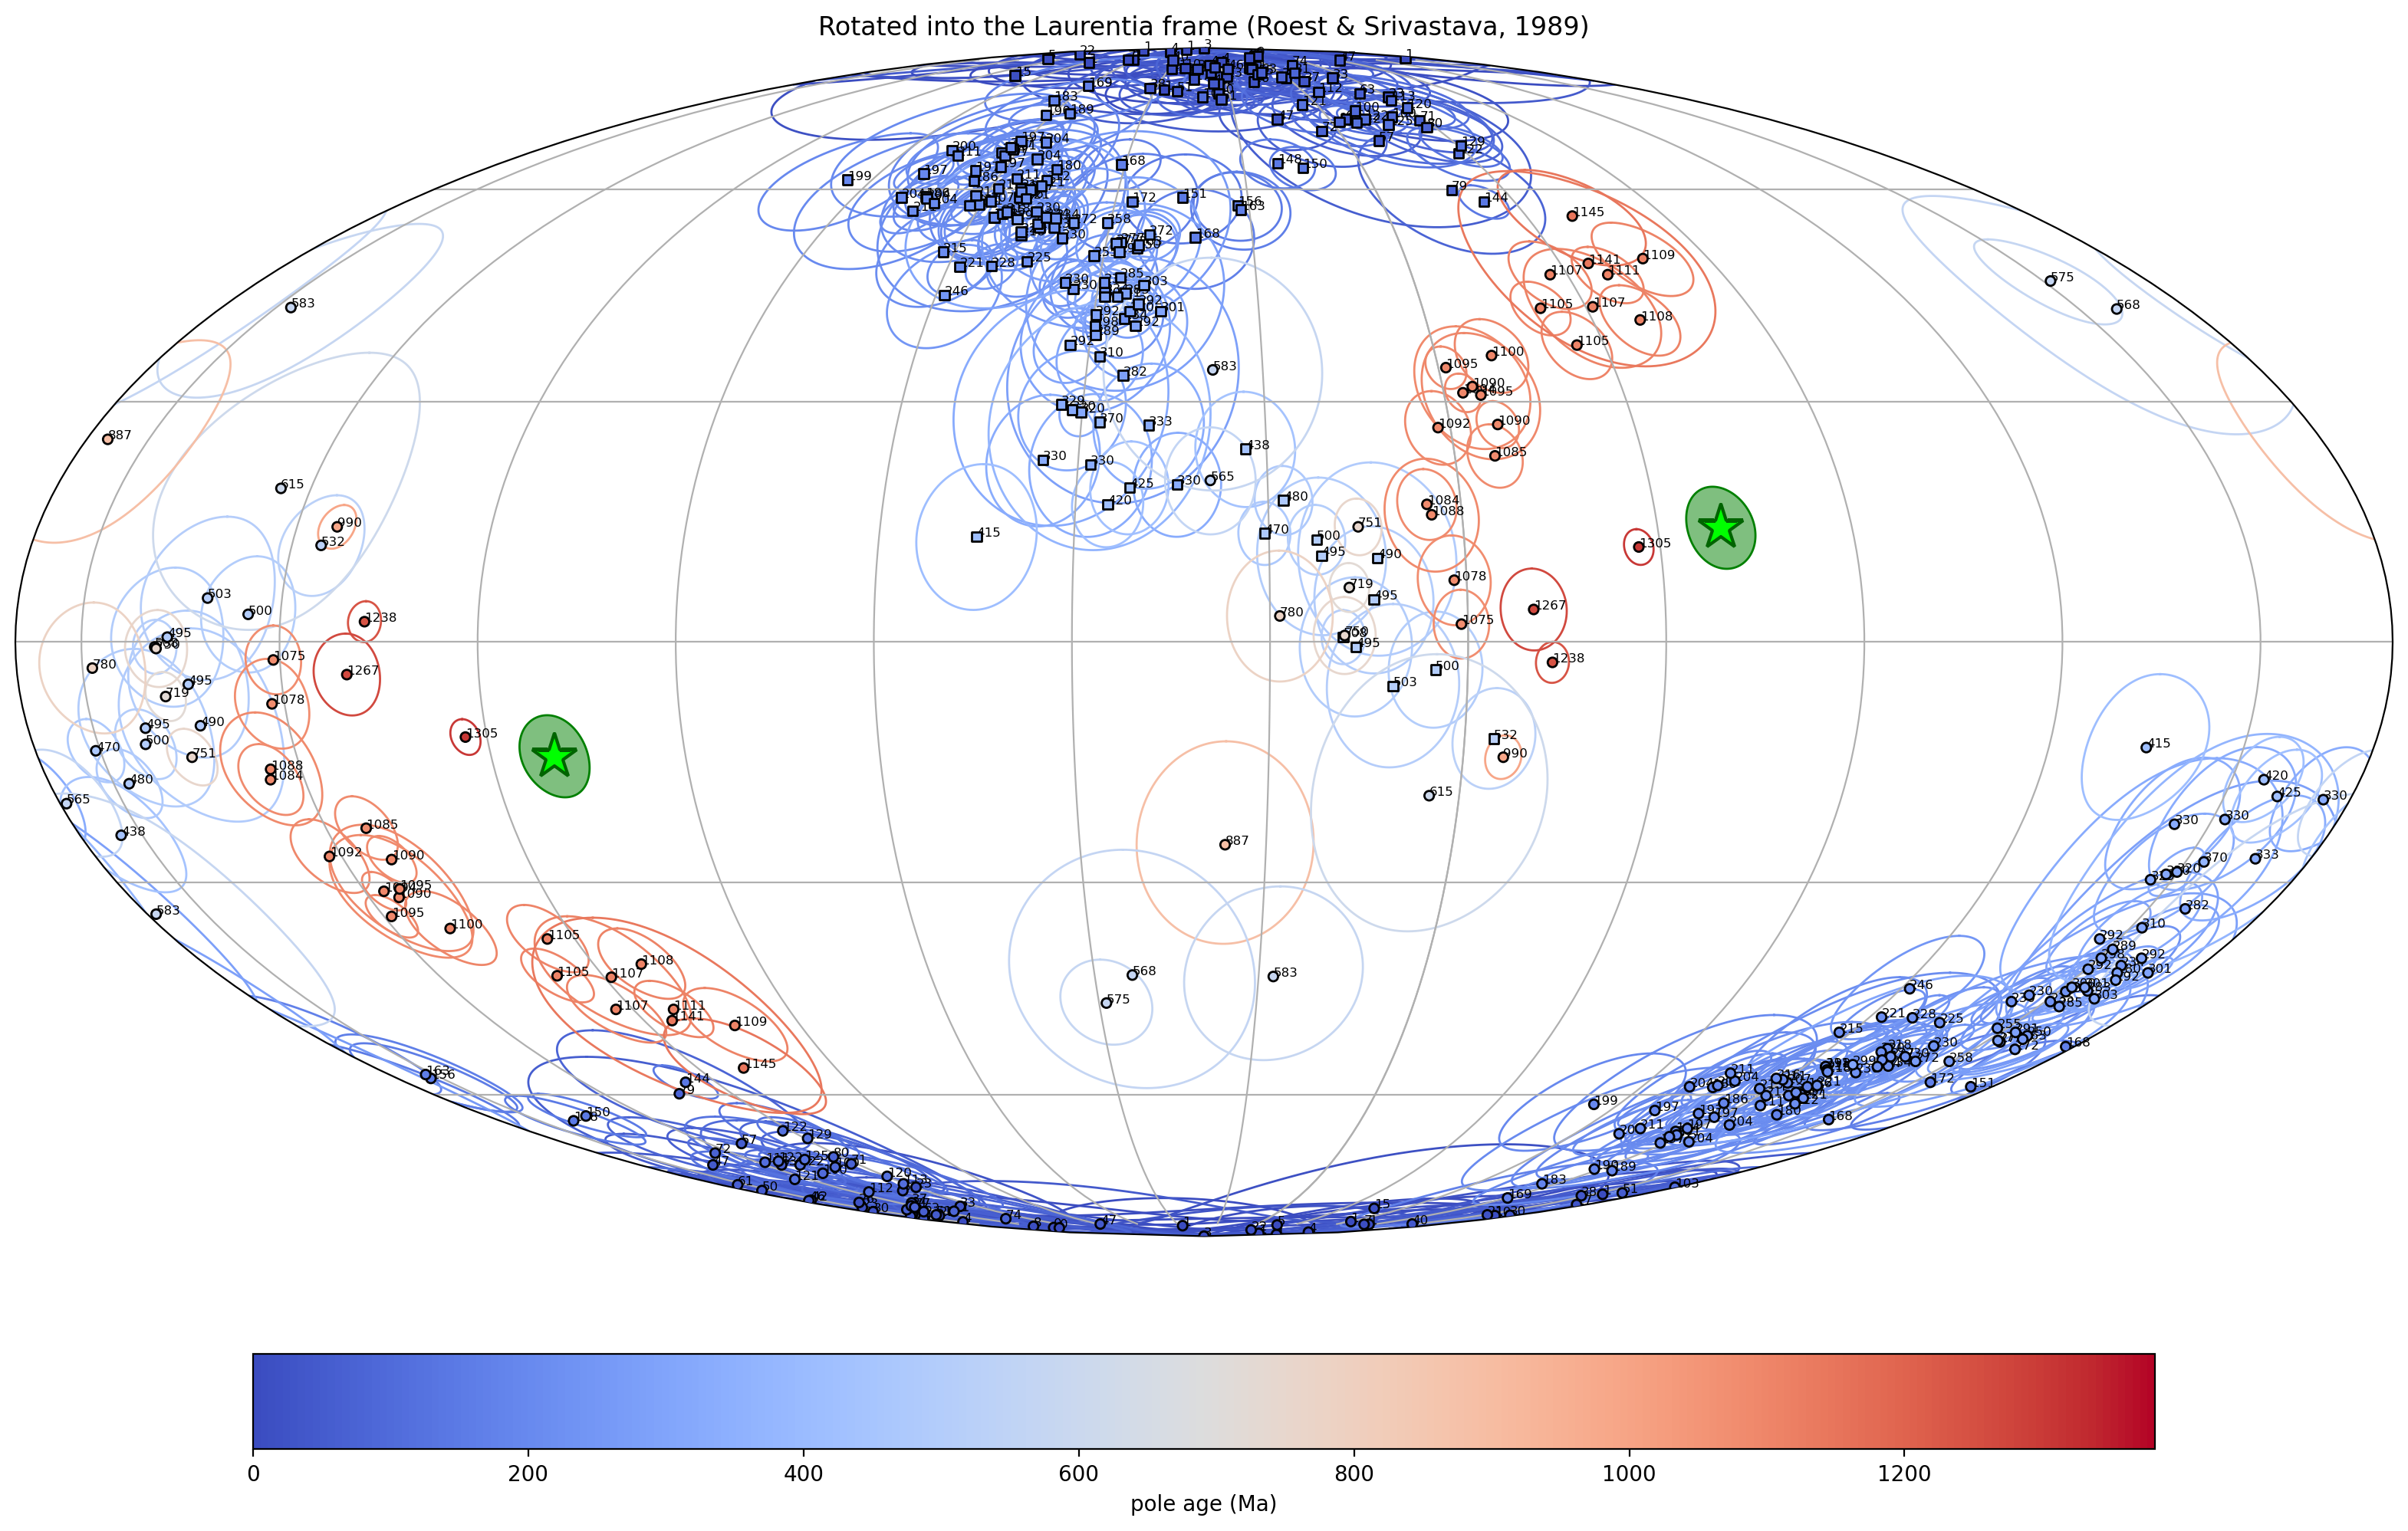

In [12]:
pt.plot_pole_overlap('Victoria Fjord dolerite dykes', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_rotated['inc'], pole_plon=pole_rotated['dec'],
                     pole_A95=pole_rotated['alpha95'], pole_age=1382, show=False)
plt.title('Rotated into the Laurentia frame (Roest & Srivastava, 1989)')
plt.show()

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | Age adopted as 1382 ± 2 Ma by correlation with the U-Pb-dated Midsommerso Dolerites (Upton et al., 2005). (The paper infers ~1.25 Ga from Rb-Sr — see note.) |
| 2 | Techniques and statistical analysis | **0** | AF + thermal demagnetization; the VGPs are over-concentrated (K ≈ 104 ≫ 70, A95 below the Deenen et al. (2011) lower bound), indicating under-averaged paleosecular variation. |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite remanence characterized by rock-magnetic measurements (Abrahamsen & Van der Voo, 1987). |
| 4 | Field tests constrain age of magnetization | **C** | Positive baked-contact test (three baked gneiss sites carry the dyke direction). |
| 5 | Structural control / tectonic coherence | **0** | Isolated nunatak exposure; possible local rotation and the unresolved age leave the structural/tectonic coherence weak. |
| 6 | Presence of reversals | **0** | Single polarity within the swarm (antiparallel to the eastern North Greenland units, but no reversal within this collection). |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles. |
| | Total | **4/7** | Grade B |

## Nordic workshop summary

The central North Greenland (Victoria Fjord) dolerite pole is recreated from the
9 dyke sites of Abrahamsen & Van der Voo (1987), after correcting the site
longitude (44.7°E → 315.3°E) and recomputing VGPs. The recreation
(≈12.7°N/231.3°E, A95 5.1°) reproduces the prior compilation Victoria Fjord pole
(10.3°N/231.7°E, GPMDB 489). Positive baked-contact test (R4 = C); over-
concentrated VGPs (R2 = 0).

**Age flag for review:** the paper infers ~1.25 Ga (Rb-Sr on related intrusives);
the compilation adopts 1382 ± 2 Ma by correlation with the U-Pb-dated Midsommerso
Dolerites — a genuine age uncertainty (R1 depends on this choice).

### Dolerite dyke pole

| | This study (site VGPs) | Abrahamsen & Van der Voo (1987) | Previous Nordic compilation |
|---|---|---|---|
| Component | Dolerite dykes | Mean of Dolerites | Dolerites & Baked |
| N (sites) | 9 | 9 | 12 |
| N (specimens) | 69 | 73 | 92 |
| Dec (°) | 266.1 | 265.2 | 265.2 |
| Inc (°) | 25.3 | 25.3 | 21.5 |
| k (direction) | 75.8 | 85 | 60.0 |
| α95 (direction, °) | 5.9 | 5.6 | 5.6 |
| Pole lat (°N) | 12.7 | 12.5 | 10.3 |
| Pole lon (°E) | 231.3 | 232.0 | 231.7 |
| A95 (°) | 5.1 | — | 4.3 |
| dp / dm (°) | — | 3.3 / 6.0 | 3.1 / 5.9 |


In [13]:
victoria_summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='Victoria Fjord dolerite dykes',
    sites=sites_geo,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='',
    tests='C+ (positive baked-contact test; three baked gneiss sites carry the dyke direction)',
    gpmdb_number='489',
    percent_reversed=0,
    demag_code=3,
    R1=1, R2=0, R3=1, R4='C', R5=0, R6=0, R7=1, Grade='B',
    nominal_age=1382, lomagage=1380, himagage=1384,
    REF_method="There is no direct radiometric dates from these dikes in the nunatak area, the age of the magnetization is inferred from the fact that the dikes' directions look to be antipodal to the directions reported from the Midsommersoe dolerite. U-Pb dating of baddeleyite from intrusive Midsommersø Dolerites yields an age of 1382 ± 2 Ma (Upton et al., 2005)",
    POLE_AUTHORS='Abrahamsen, N., & Van der Voo, R.',
    YEAR=1987,
    JOURNAL='Geophysical Journal of the Royal Astronomical Society',
    VOLUME='91',
    VPAGES='597-611',
    TITLE='Palaeomagnetism of middle Proterozoic (c. 1.25 Ga) dykes from central North Greenland',
    COMMENT='Departs from previous nordic compilation by being the mean of the dikes rather than dikes and baked. Recalculated from the VGPs as documented in Swanson-Hysell et al. 2026.'
)
pt.save_nordic_summary(victoria_summary, '1382_Victoria_Fjord')
victoria_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,Victoria Fjord dolerite dykes,GPMDB:489,,C+ (positive baked-contact test; three baked g...,0,81.5,315.3,9,69,...,1384,There is no direct radiometric dates from thes...,Victoria Fjord dolerite dykes,"Abrahamsen, N., & Van der Voo, R.",1987,Geophysical Journal of the Royal Astronomical ...,91,597-611,Palaeomagnetism of middle Proterozoic (c. 1.25...,Departs from previous nordic compilation by be...
